# TS0: Primeros pasos en la simulación

### **Alumno:** Matías Carbajal

### Materia: Análisis y Procesamiento de Señales (APS)

### Carrera: Ingeniería Telecomunicaciones 

### Fecha: 20 de agosto de 2026

## 1. Introducción teórica

### 1.1. Señal senoidal en tiempo continuo y discreto

Una señal senoidal analógica en el tiempo continuo $t$ se define matemáticamente mediante la siguiente expresión:

$$x(t) = V_{\text{max}} \cdot \sin(2\pi \cdot f \cdot t + \phi) + DC$$

Donde:
* $V_{\text{max}}$: **Amplitud pico de la señal**, expresada en volts $[V]$.
* $f$: **Frecuencia temporal**, expresada en Hertz $[\text{Hz}]$.
* $\phi$: **Fase inicial**, expresada en radianes $[\text{rad}]$.
* $DC$: **Valor medio o componente continua (*offset*)**, expresado en volts $[V]$.



#### Discretización de la señal
En el procesamiento digital de señales, el tiempo continuo $t$ se muestrea a intervalos discretos uniformes de duración $T_s = 1/f_s$, donde $f_s$ representa la **frecuencia de muestreo** $[\text{Hz}]$. Al reemplazar $t = n \cdot T_s = \frac{n}{f_s}$, se obtiene la secuencia en tiempo discreto $x[n]$:

$$x[n] = V_{\text{max}} \cdot \sin\left(2\pi \cdot \frac{f}{f_s} \cdot n + \phi\right) + DC$$

Para $n = 0, 1, 2, \dots, N-1$, donde $n$ representa el índice discreto de la muestra y $N$ la cantidad total de puntos tomados.


### 1.3. Teorema de muestreo y frecuencia de Nyquist

Para poder reconstruir correctamente una señal limitada en banda a partir de sus muestras, la frecuencia de muestreo debe ser al menos el doble de la máxima frecuencia presente en la señal:

$$f_s \ge 2 \cdot f_{\text{máx}}$$

La frecuencia:

$$f_N = \frac{f_s}{2}$$

se denomina frecuencia de Nyquist.

Cuando una señal posee una frecuencia superior a $f_s/2$, pueden producirse errores de representación conocidos como *aliasing*. En este fenómeno, distintas frecuencias analógicas pueden producir el mismo conjunto de muestras digitales, haciendo que una señal de alta frecuencia sea interpretada como una señal de menor frecuencia.
Esto será analizado posteriormente mediante los experimentos con $f_s = 1000\text{ Hz}$ y las frecuencias de $500\text{ Hz}$, $999\text{ Hz}$, $1001\text{ Hz}$ y $2001\text{ Hz}$.

## 2.1. Gráfica de señales

### 2.1.1 Codigo

**Importación de Librerías**

In [9]:
import matplotlib.pyplot as plt
import numpy as np

**Función Generadora mi_funcion_sen**

In [10]:
N=  1000 #MUESTRAS
fs= 1000 #HZ

In [3]:
def mi_funcion_sen(vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    tt = np.arange(0, N/fs, 1/fs)
    xx = dc + vmax * np.sin(2* np.pi * tt * ff + ph )
    return (tt, xx)


**Parametros:**

In [26]:
vmax = 1.5
dc = 1
ff = 500
ph = 0

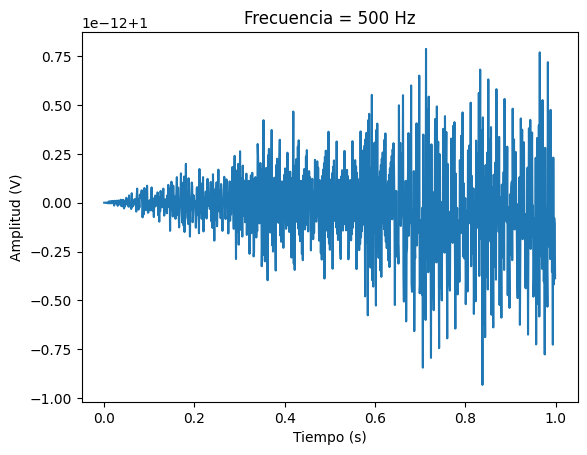

In [27]:
tt, xx = mi_funcion_sen(vmax = vmax, dc = dc, ff = ff, ph=ph, nn = N, fs = fs)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.title('Frecuencia = 500 Hz')
plt.plot(tt, xx)

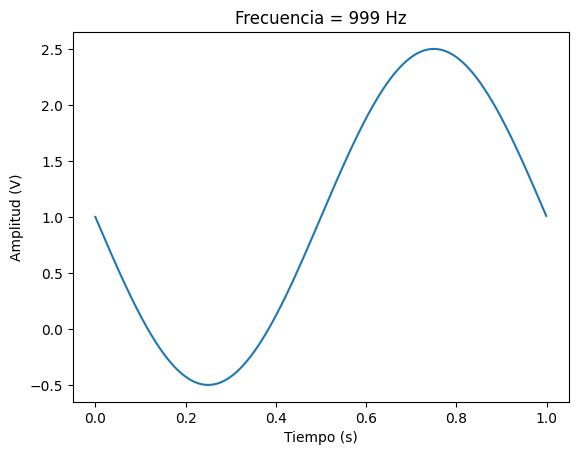

In [28]:
ff=999
tt, xx = mi_funcion_sen(vmax = vmax, dc = dc, ff = ff, ph=ph, nn = N, fs = fs)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.title('Frecuencia = 999 Hz')
plt.plot(tt, xx)

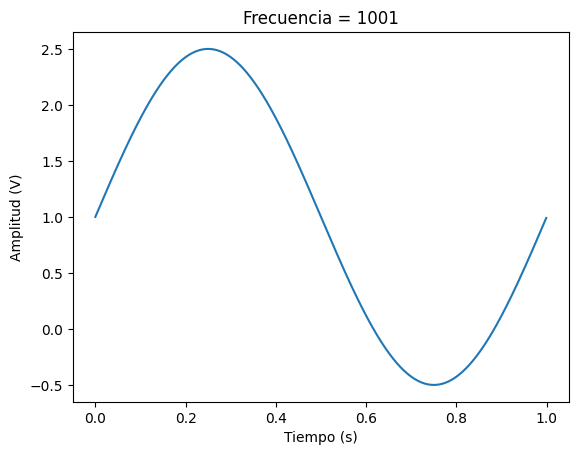

In [31]:
ff=1001
tt, xx = mi_funcion_sen(vmax = vmax, dc = dc, ff = ff, ph=ph, nn = N, fs = fs)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.title('Frecuencia = 1001')
plt.plot(tt, xx)

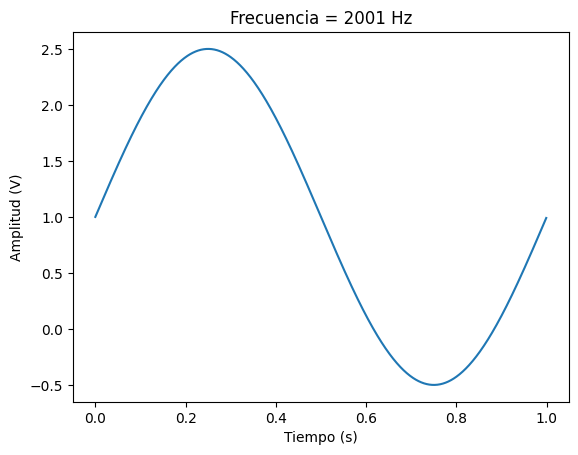

In [33]:
ff=2001
tt, xx = mi_funcion_sen(vmax = vmax, dc = dc, ff = ff, ph=ph, nn = N, fs = fs)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.title('Frecuencia = 2001 Hz')
plt.plot(tt, xx)

## 3. Análisis de resultados y demostración analítica del Aliasing

### 3.1. Justificación Matemática
Al muestrear una senoidal $x(t) = \sin(2\pi \cdot f \cdot t)$, la secuencia en tiempo discreto obtenida es:

$$x[n] = \sin\left(2\pi \frac{f}{f_s} n\right)$$

Consideremos ahora una frecuencia general $f' = k \cdot f_s + f$, con $k \in \mathbb{Z}$. Al reemplazar $f'$ en la ecuación de muestreo se obtiene:

$$x_{f'}[n] = \sin\left(2\pi \frac{k \cdot f_s + f}{f_s} n\right) = \sin\left(2\pi k n + 2\pi \frac{f}{f_s} n\right)$$

Dado que $k \cdot n$ es siempre un número entero, la adición de $2\pi (k \cdot n)$ dentro del argumento de la función seno no altera su valor debido a la periodicidad de $2\pi$:

$$x_{f'}[n] = \sin\left(2\pi \frac{f}{f_s} n\right) = x[n]$$


### 3.2. Evaluación de los Casos Experimentales ($f_s = 1000\text{ Hz}$)

Tomando la frecuencia de muestreo del experimento $f_s = 1000\text{ Hz}$ (lo que define una frecuencia de Nyquist $f_N = 500\text{ Hz}$):

1. **Caso $f = 500\text{ Hz}$ ($f = f_N$):**  
   $$x[n] = \sin\left(2\pi \frac{500}{1000} n\right) = \sin(\pi n) = 0 $$  
   *Se encuentra justo en el límite de Nyquist. Las muestras caen exactamente en los cruces por cero de la senoide.*

2. **Caso $f = 999\text{ Hz}$ ($f = f_s - 1\text{ Hz}$):**  
   $$x[n] = \sin\left(2\pi \frac{1000 - 1}{1000} n\right) = \sin\left(2\pi n - 2\pi \frac{1}{1000} n\right) = -\sin\left(2\pi \frac{1}{1000} n\right)$$  
   *Produce una tono de $1\text{ Hz}$ aliaseado (con oposición de fase).*

3. **Caso $f = 1001\text{ Hz}$ ($f = f_s + 1\text{ Hz}$):**  
   $$x[n] = \sin\left(2\pi \frac{1000 + 1}{1000} n\right) = \sin\left(2\pi n + 2\pi \frac{1}{1000} n\right) = \sin\left(2\pi \frac{1}{1000} n\right)$$  
   *Corresponde exactamente al caso $f' = f_s + f$ con $k=1$ y $f=1\text{ Hz}$. La secuencia de muestras es indistinguible de una senoidal pura de $1\text{ Hz}$.*

4. **Caso $f = 2001\text{ Hz}$ ($f = 2f_s + 1\text{ Hz}$):**  
   $$x[n] = \sin\left(2\pi \frac{2\cdot 1000 + 1}{1000} n\right) = \sin\left(4\pi n + 2\pi \frac{1}{1000} n\right) = \sin\left(2\pi \frac{1}{1000} n\right)$$  
   *Corresponde a $k=2$ y $f=1\text{ Hz}$. Nuevamente, las muestras se pliegan y reproducen exactamente la misma señal discreta de $1\text{ Hz}$.*

---

### 3.3. Resumen y Conclusiones del Experimento

Los resultados confirman experimentalmente que cuando se viola el teorema de Nyquist-Shannon ($f > f_s/2$), el sistema digital es incapaz de discriminar la frecuencia real de la señal analógica original, interpretando las componentes de alta frecuencia como componentes pertenecientes a la banda base $[0, f_s/2]$.